This Python notebook evaluates the training of the MobileViT-Small model. Its purpose is to provide a comparison of the three optimisers used during training: Adam, RMSprop, and SGD. This is achieved by loading the best saved model configuration for each optimiser, evaluating performance on the unseen test split, and presenting the results through print statements, tables, and visualisations. This notebook will also include discussion of the findings and a conclusion on which optimiser is most suitable for use in the Spot Check Medical web application.

In [2]:
#Name: Craig McMillan
#Student Number: 2390641
#Date: 14/03/26
#Testing, evaluaition and visualisation of model performance, including plots and graphs 

#importing libraries
import os
import torch
import torch.nn as nn
import cv2
from torch.utils.data import Dataset, DataLoader
from transformers import AutoImageProcessor, MobileViTForImageClassification
from sklearn.metrics import (accuracy_score, precision_score, average_precision_score, recall_score,f1_score, roc_auc_score, roc_curve, classification_report)
from sklearn.metrics import PrecisionRecallDisplay, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/craig/Documents/GitHub/melanoma_webapp_classifier/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The available device will first be detected and assigned. This ensures the evaluation runs on the most appropriate hardware available, while also allowing the notebook to remain portable across different systems.

In [3]:
#selecting device based on platform
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    chosenDevice = torch.device("mps")
elif torch.cuda.is_available():
    chosenDevice = torch.device("cuda")
else:
    chosenDevice = torch.device("cpu")
print(f"Device selected {chosenDevice}")

Device selected mps


The main file paths and evaluation settings are defined in this section. These include the pretrained model location, cleaned image dataset location, trained model directory, batch size, classification threshold, and optimiser list.

These settings are kept consistent throughout the notebook so that the evaluation remains reproducible and the optimiser results can be compared fairly.

In [4]:
#setting file paths for loading inputs and saving outputs
modelWeights = "/Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/hf/apple_mobilevit_small"
imgDataset = "/Users/craig/Desktop/TrainingData/cleanedData_Final"
trained = "/Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained"

#settings main variables
batchSize = 16
threshold = 0.5
numWorkers = 0
optimiserList = ["adam", "rmsprop", "sgd"]

The unseen test split will be loaded, along with basic dataset information printed to confirm the correct file has been loaded and to show the number of benign and malignant samples present.

In [5]:
#loading saved test_split.csv file from directory
testSplitPath = os.path.join(trained, "test_split.csv")
test_df = pd.read_csv(testSplitPath)
#calculating target classes based on content on dataframe
testImages = len(test_df)
testBenign = (test_df["target"] == 0).sum()
testMalignant = (test_df["target"] == 1).sum()
#printing test split to view content
print(f"Test split loaded from {testSplitPath}")
print(f"Test set contains {testImages} images")
print(f"Benign image count: {testBenign}")
print(f"Malignant image count: {testMalignant}")

Test split loaded from /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/test_split.csv
Test set contains 4937 images
Benign image count: 4852
Malignant image count: 85


The image processor used during model training will be loaded along with a print statement displaying the configuration. This ensures that the test images are prepared in the same format as the training and validation images, which is necessary for consistent evaluation.

In [6]:
#loading default processor configuration
processor = AutoImageProcessor.from_pretrained(modelWeights, use_fast=False)
print("Processor loaded")
print(processor)

Processor loaded
MobileViTImageProcessor {
  "crop_size": {
    "height": 256,
    "width": 256
  },
  "do_center_crop": true,
  "do_flip_channel_order": true,
  "do_flip_channels": true,
  "do_reduce_labels": false,
  "do_rescale": true,
  "do_resize": true,
  "image_processor_type": "MobileViTImageProcessor",
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "shortest_edge": 288
  }
}



The results show the default configuration.

Next, a SkinLesionDataset class will be defined using __init__, __len__, __getitem__ to load images from the filenames stored in the CSV file. This will allow the dataset to return both the processed image tensor and its label for model evaluation. Images will then be loaded using OpenCV and passed through the same processor configuration used during training, ensuring that preprocessing will remain consistent across both stages. The processor will also be configured with do_resize=False and do_center_crop=False to match the training setup, since the resizing and padding of images have already been applied at an earlier stage in development

In [7]:
#defining SkinLesionDataset class for loading images and labels from the dataset
class SkinLesionDataset(Dataset):
    #defining __init__ method for storing the loaded csv files, loading images and image preprocessor
    def __init__(self, loadedCSV, imgDataset, processor):
        self.csvData = loadedCSV.reset_index(drop=True)
        self.imgData = imgDataset
        self.processor = processor
    #defining __len__ function that returns total number of rows in the dataset
    def __len__(self):
        dataCount = len(self.csvData)
        return dataCount
    #defining __getitem__ function that loads a single image and label based on the index and processes the image
    def __getitem__(self, index):
        currentRow = self.csvData.iloc[index]
        targetLabel = int(currentRow["target"])
        filename = f"cleaned_{currentRow['image_name']}.jpg"
        imagePath = os.path.join(self.imgData, filename)
        loadedImage = cv2.imread(imagePath)
        #throws error if image cannot be loaded
        if loadedImage is None:
            raise FileNotFoundError(f"Error, could not load image {imagePath}")
        #processes images and returns tensors
        processedImage = self.processor(images=loadedImage, return_tensors="pt", do_resize=False, do_center_crop=False)["pixel_values"].squeeze(0)
        targetTensor = torch.tensor(targetLabel, dtype=torch.float32)
        return processedImage, targetTensor
print("Class created")

Class created


The print statements confirms that the class was created successfully.

The testLoader will be created and loaded with the SkinLesionDataset, shuffle will be set to false to preserve the sample order during evaluation and num_workers will be set to 0 to avoid instability in the notebook environment. A print confirmation will show this was successful

A confirmation message will be printed to show that the testLoader has been created successfully and to report how many batches will be processed during evaluation.

In [8]:
#loading the data for testing
testLoader = DataLoader(
    SkinLesionDataset(test_df, imgDataset, processor),
    batch_size=batchSize,
    shuffle=False,
    num_workers=numWorkers
)
#counting and printing the test batches
testBatches = len(testLoader)
print(f"testLoader created with {testBatches} batches, shuffle = False and num workers = {numWorkers}  ")

testLoader created with 309 batches, shuffle = False and num workers = 0  


A evaluateSavedModel will be created to load the pretrained model and configured for binary classification. This function loads a saved model, the model weights, and will run the model with the test set. This will return the true labels, predicted labels, and predicted probabilities. Finally, a print statement will confirm the data has been loaded.

In [9]:
#defining evaluateSavedModel function 
def evaluateSavedModel(savedModelPath, testLoader, device):

    #load model and classifier
    model = MobileViTForImageClassification.from_pretrained(modelWeights)
    inputFeatures = model.classifier.in_features
    model.classifier = nn.Linear(inputFeatures, 1)

    #load saved model weights ready for evaluation
    savedModel = torch.load(savedModelPath, map_location=device)
    model.load_state_dict(savedModel["state_dict"])
    model = model.to(device)
    model.eval()

    #get data from saved model
    savedEpoch = savedModel["epoch"]
    savedOptimiserName = savedModel["optimiser_name"]
    #print to confirm saved data

    print(f"Loaded {savedOptimiserName} and best weights from epoch {savedEpoch}")
    
    #creating lists for data
    labelsList = []
    predictionsList = []
    probabilitiesList = []

        #turning off gradient calculation during evaluation to use less memory
    with torch.no_grad():
        #loop over dataset
        for batchNum, (inputs, labels) in enumerate(testLoader):
            inputs = inputs.to(device)
            outputs = model(inputs).logits.squeeze(1)
            
            #converting logits into predicted labels
            predictedProbabilities = torch.sigmoid(outputs).cpu().numpy()
            predictedLabels = (predictedProbabilities >= threshold).astype(int)
            
            #storing resuts data in list
            probabilitiesList.extend(predictedProbabilities)
            predictionsList.extend(predictedLabels)
            labelsList.extend(labels.numpy().astype(int))

            #print batch progress to track evaluation
            if batchNum % 50 == 0:
                print(f"Batch {batchNum}/{len(testLoader)}")

    #convert lists to np.arrays
    labelsList = np.array(labelsList)
    predictionsList = np.array(predictionsList)
    probabilitiesList = np.array(probabilitiesList)

    #return values and print
    return labelsList, predictionsList, probabilitiesList
print("evaluateSavedModel function configured")

evaluateSavedModel function configured


Each saved optimiser model will now be evaluated on the unseen test dataset. Performance metrics including accuracy, precision, recall, F1 score, and ROC AUC will be calculated, and stored to use for comparison. Finally, the results will be printed in their basic format before moving on to the more detailed visual comparisons.

In [10]:
#creating dictionary to store evaluation results
allResults = {}

#loop over the optimiser list
for currentOptimiser in optimiserList:
    savedModelPath = os.path.join(trained, f"best_{currentOptimiser}.pth")
    savedModelExists = os.path.exists(savedModelPath)
    
    #check for saved model data before evaluating
    if savedModelExists:
        print(f"Evaluating {currentOptimiser}")
        print("--")
        #run evaluation and return the data
        labels, predictions, probabilities = evaluateSavedModel(savedModelPath, testLoader, chosenDevice)
        
        #clacualte the results based on the saved metrics
        accuracyResult = accuracy_score(labels, predictions)
        precisionResult = precision_score(labels, predictions, zero_division=0)
        recallResult = recall_score(labels, predictions, zero_division=0)
        f1Result = f1_score(labels, predictions, zero_division=0)
        rocAucResult = roc_auc_score(labels, probabilities)
        avgPrecisionResult = average_precision_score(labels, probabilities)
        
        #storing the results data from current optimiser
        allResults[currentOptimiser] = {
            "labels": labels,
            "predictions": predictions,
            "probabilities": probabilities,
            "metrics": {
                "Accuracy": round(accuracyResult, 4),
                "Precision": round(precisionResult, 4),
                "Recall": round(recallResult, 4),
                "F1 Score": round(f1Result, 4),
                "ROC AUC": round(rocAucResult, 4),
                "Average Precision": round(avgPrecisionResult, 4)
            }
        }
        #print the evaluation metrics for current selection optimiser
        print("--")
        print(f"Accuracy: {round(accuracyResult, 4)}")
        print(f"Precision: {round(precisionResult, 4)}")
        print(f"Recall: {round(recallResult, 4)}")
        print(f"F1 Score: {round(f1Result, 4)}")
        print(f"ROC AUC: {round(rocAucResult, 4)}")
        print("--")
        print()
#print to confirm evaluation of all optimisers in the list
print(f"{len(allResults)} of {len(optimiserList)} optimisers evaluated")

Evaluating adam
--


Loading weights: 100%|██████████| 347/347 [00:00<00:00, 1980.15it/s, Materializing param=mobilevit.encoder.layer.4.transformer.layer.2.output.dense.weight]                        


Loaded adam and best weights from epoch 7
Batch 0/309
Batch 50/309
Batch 100/309
Batch 150/309
Batch 200/309
Batch 250/309
Batch 300/309
--
Accuracy: 0.6154
Precision: 0.0405
Recall: 0.9412
F1 Score: 0.0777
ROC AUC: 0.8783
--

Evaluating rmsprop
--


Loading weights: 100%|██████████| 347/347 [00:00<00:00, 1845.12it/s, Materializing param=mobilevit.encoder.layer.4.transformer.layer.2.output.dense.weight]                        


Loaded rmsprop and best weights from epoch 7
Batch 0/309
Batch 50/309
Batch 100/309
Batch 150/309
Batch 200/309
Batch 250/309
Batch 300/309
--
Accuracy: 0.7276
Precision: 0.0519
Recall: 0.8588
F1 Score: 0.0979
ROC AUC: 0.8837
--

Evaluating sgd
--


Loading weights: 100%|██████████| 347/347 [00:00<00:00, 1939.40it/s, Materializing param=mobilevit.encoder.layer.4.transformer.layer.2.output.dense.weight]                        


Loaded sgd and best weights from epoch 10
Batch 0/309
Batch 50/309
Batch 100/309
Batch 150/309
Batch 200/309
Batch 250/309
Batch 300/309
--
Accuracy: 0.7979
Precision: 0.0697
Recall: 0.8706
F1 Score: 0.1291
ROC AUC: 0.9024
--

3 of 3 optimisers evaluated


The printed test metrics provide the first direct comparison between Adam, RMSprop, and SGD.

The training results show that both Adam and RMSprop achieved their lowest validation loss at epoch 7, while SGD achieved its lowest validation loss at epoch 10 after completing the full 10 epochs.

Adam achieved an accuracy of 0.6154, precision of 0.0405, recall of 0.9412, F1 score of 0.0777, and ROC AUC of 0.8783.

RMSprop achieved an accuracy of 0.7276, precision of 0.0519, recall of 0.8588, F1 score of 0.0979, and ROC AUC of 0.8837.

SGD achieved an accuracy of 0.7979, precision of 0.0697, recall of 0.8706, F1 score of 0.1291, and ROC AUC of 0.9024.

The data shows that SGD achieved the strongest overall performance across most metrics, recording the highest test accuracy, precision, F1 score, and ROC AUC. Adam achieved the highest recall, meaning it was the most sensitive to malignant cases, but this also resulted in the highest number of false positives. RMSprop generally produced results between Adam and SGD.

These values show that accuracy alone does not provide a complete picture of model performance. Because the dataset is imbalanced, further visualisations are required to examine this behaviour in more detail. A classification report will be created, as it gives a clearer breakdown of benign and malignant performance separately.

In [11]:
#loop over optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in allResults:
        continue
    #get labels and preciditon from current optimiser results
    classificationLabels = allResults[currentOptimiser]["labels"]
    classificationPredictions = allResults[currentOptimiser]["predictions"]
    #print the classification details from currrent optimiser
    print(f"Displaying classification report for {currentOptimiser}")
    print()
    print(classification_report(classificationLabels, classificationPredictions, digits=4, target_names=["Benign", "Malignant"]))

Displaying classification report for adam

              precision    recall  f1-score   support

      Benign     0.9983    0.6096    0.7570      4852
   Malignant     0.0405    0.9412    0.0777        85

    accuracy                         0.6154      4937
   macro avg     0.5194    0.7754    0.4174      4937
weighted avg     0.9818    0.6154    0.7453      4937

Displaying classification report for rmsprop

              precision    recall  f1-score   support

      Benign     0.9966    0.7253    0.8396      4852
   Malignant     0.0519    0.8588    0.0979        85

    accuracy                         0.7276      4937
   macro avg     0.5243    0.7920    0.4687      4937
weighted avg     0.9803    0.7276    0.8268      4937

Displaying classification report for sgd

              precision    recall  f1-score   support

      Benign     0.9972    0.7966    0.8857      4852
   Malignant     0.0697    0.8706    0.1291        85

    accuracy                         0.7979      49

The classification report created for each of the three optimisers provides a clearer presentation of the evaluation results. This output is useful because it separates benign and malignant results rather than combining them into single overall values. It also includes a support column, which shows how many samples from each class are present in the test set. In addition, the report includes macro average and weighted average scores. The macro average gives equal importance to each class, regardless of how many samples it contains, while the weighted average takes class size into account and is therefore influenced more heavily by the majority benign class.

The reports show that all three models performed very strongly on the benign class, with precision values remaining close to 1.0 and recall generally ranging from around 0.61 to 0.80. In contrast, performance on the malignant class was much weaker, particularly for precision, which remained very low across all three models at roughly 0.04 to 0.07. Adam achieved the highest malignant recall at 0.9412, but this came with very low precision, meaning that many benign images were incorrectly flagged as malignant. SGD produced the best malignant precision at 0.0697 and the highest malignant F1 score at 0.1291, suggesting a better balance between detecting malignant cases and limiting false positives.

This output confirms that the models learned the two classes unevenly, which is expected given the class imbalance. The difference is also reflected in the macro average F1 scores, which ranged from 0.4174 to 0.5074, showing that overall class performance was less balanced than the weighted averages alone suggested. 

To better visualise the data, the key metrics will next be displayed in a comparison table, this will be used as reference in the report.

In [12]:
#setting metrics dictionary 
metricsDict = {}
#loop over the optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser in allResults:
        #storing metics
        metricsDict[currentOptimiser] = allResults[currentOptimiser]["metrics"]
#setting, printing and displaying comparison table
comparisonTable = pd.DataFrame(metricsDict)
print("Displaying optimiser comparison table below")
display(comparisonTable)

Displaying optimiser comparison table below


,adam,rmsprop,sgd
Accuracy,0.6154,0.7276,0.7979
Precision,0.0405,0.0519,0.0697
Recall,0.9412,0.8588,0.8706
F1 Score,0.0777,0.0979,0.1291
ROC AUC,0.8783,0.8837,0.9024
Average Precision,0.1034,0.1419,0.1821


This comparison table presents the main metrics for all three optimisers in a compact table format. This is becuase exact values are easier to compare side by side than they are in printed output alone. This allows the strongest and weakest optimiser for each metric to be identified at a glance.

Confusion matrices will next be used to show how each optimiser classified benign and malignant samples. Two versions will be displayed for each optimiser: A raw count matrix displayed on the left and a normalised matrix displayed on the right. The raw version shows the count of correct and incorrect predictions, while the normalised version shows the percentage of correct and incorrect predictions within each true class. This visualisation makes false positives and false negatives easier to identify than summary metrics alone.

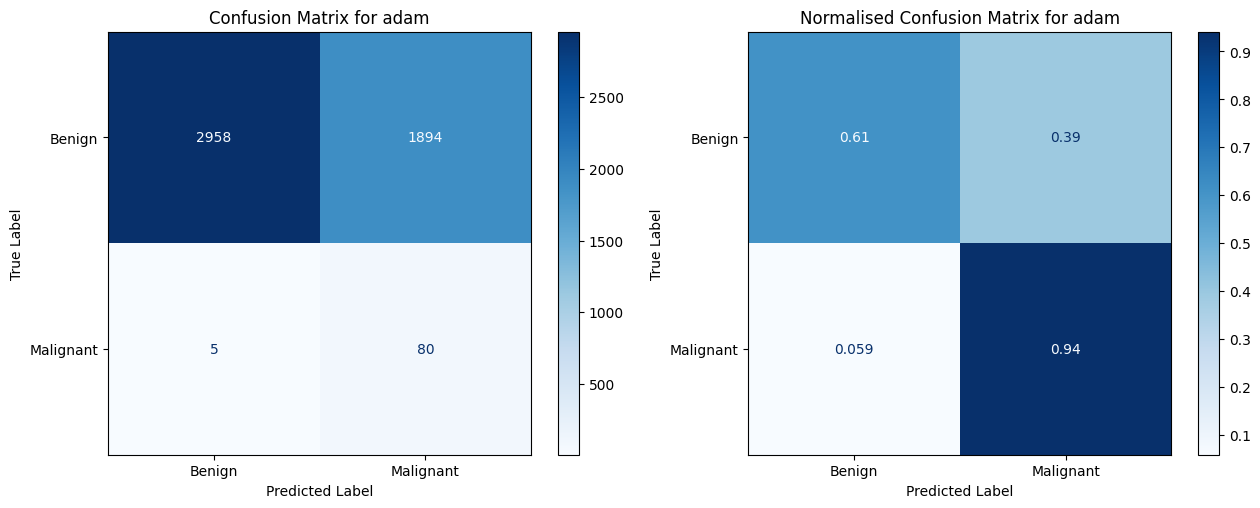

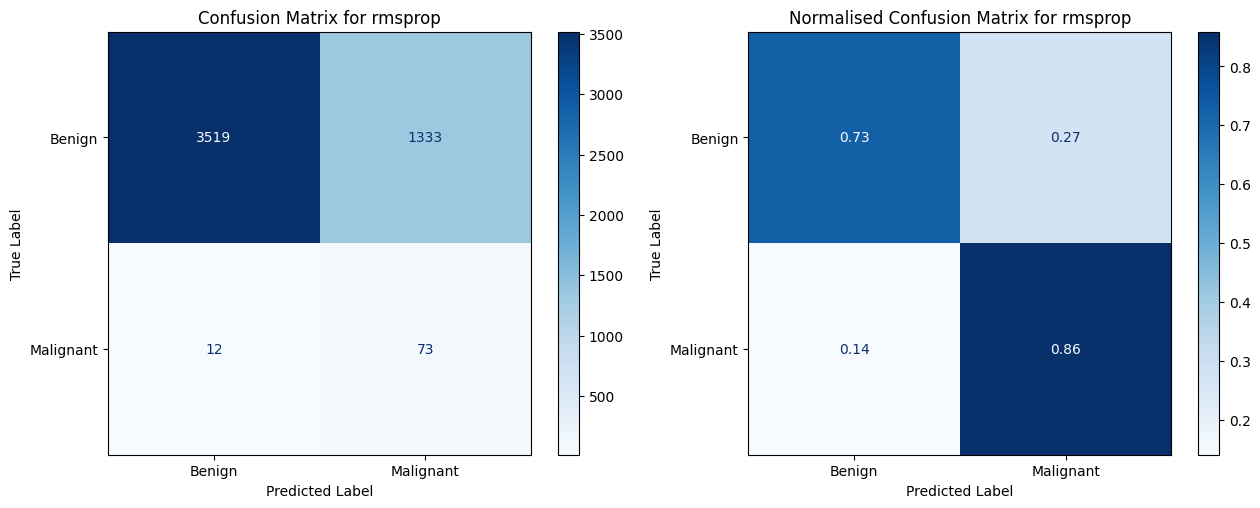

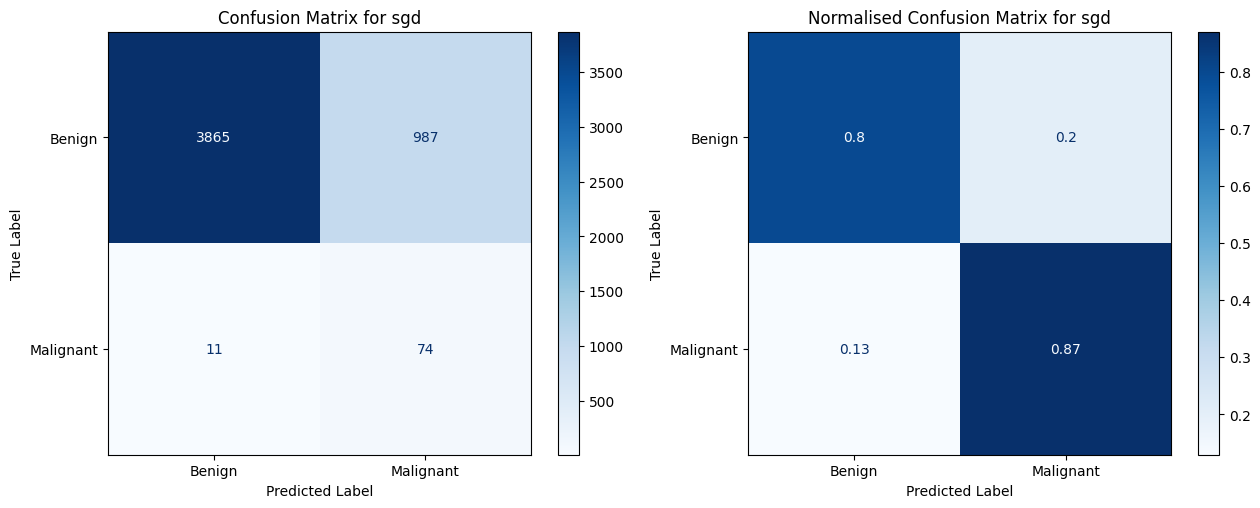

In [ ]:
#looping over the optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in allResults:
        continue
    #getting labels abd predictions
    labels = allResults[currentOptimiser]["labels"]
    predictions = allResults[currentOptimiser]["predictions"]

    #configuring the 
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    #creating the standard confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, predictions,
        display_labels=["Benign", "Malignant"],
        cmap=plt.cm.Blues,
        normalize=None,
        ax=axes[0]
    )
    #setting title and labels of first matrix
    axes[0].set_title(f"Confusion Matrix for {currentOptimiser}")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")
    
    #creating the normalised confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, predictions,
        display_labels=["Benign", "Malignant"],
        cmap=plt.cm.Blues,
        normalize="true",
        ax=axes[1]
    )
    #setting title and labels of second matrix
    axes[1].set_title(f"Normalised Confusion Matrix for {currentOptimiser}")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")
    #shrinking layout to fit better side by side
    plt.tight_layout()
    #saving to file and then printing and displaying matrices
    savePath = os.path.join(trained, f"confusion_matrix_{currentOptimiser}.png")
    plt.savefig(savePath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {savePath}")

The confusion matrices show that all three models favoured malignant recall over benign precision to some extent. Adam produced the highest number of malignant detections, but it also gave the highest number of benign samples incorrectly classified as malignant. RMSprop reduced this slightly, while SGD showed the strongest overall balance between correct benign classification and malignant detection.

The colour intensity helps make this easier to interpret across all six matrices. In each plot, darker blue cells represent larger values, while lighter cells represent smaller values. In the raw confusion matrices, this reflects the number of predictions in each category. In the normalised confusion matrices, the colour instead reflects the proportion of predictions within each true class. This helps show more clearly where the model is concentrating most of its predictions, either as counts or percentages.

Across all three raw confusion matrices, the top left cell is the darkest, showing that the largest number of predictions were correct benign classifications. The top right cells are also fairly dark, particularly for Adam, which shows that a substantial number of benign images were incorrectly classified as malignant. In contrast, the bottom row is lighter overall because the malignant class contains far fewer samples. However, the bottom right cell remains darker than the bottom left cell in each case, showing that most malignant samples were still correctly identified.

The normalised confusion matrices make this pattern easier to see by showing the results as percentages rather than raw counts. Adam shows the darkest bottom right cell at 0.94, confirming that it achieved the highest malignant recall, but its top right value of 0.39 is also the highest, showing the largest false positive rate for benign cases. RMSprop reduced this benign misclassification rate to 0.27, while SGD reduced it further to 0.20. At the same time, SGD still maintained a strong malignant recall of 0.87, which was below the score achieved by Adam but close to RMSprop at 0.86.

Overall, the normalised confusion matrices show that Adam was the most aggressive at identifying malignant cases, whereas SGD maintained better control over false positives while still detecting most malignant samples. This supports the earlier precision and recall results and helps explain more clearly why SGD achieved the best overall test performance.

The following overlaid ROC curves help show how well each optimiser separated the two classes across different threshold values.

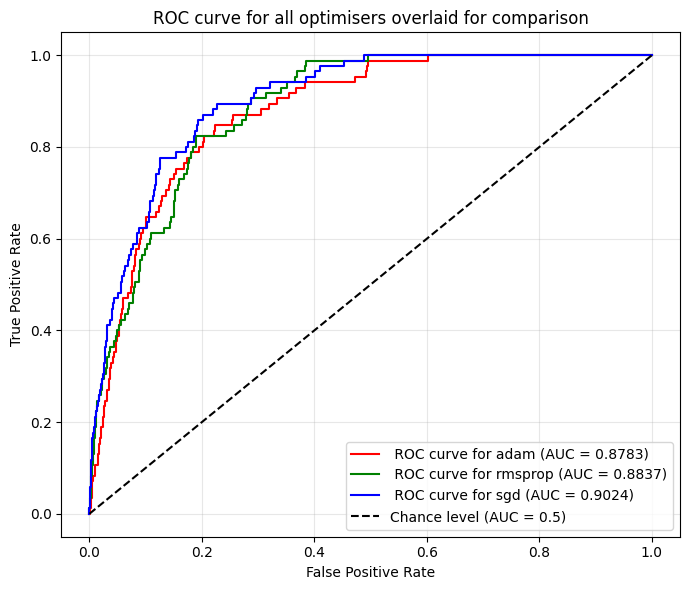

In [ ]:
#set optimiser colours
optimiserColours = {"adam": "red", "rmsprop": "green", "sgd": "blue"}
#configure plot
plt.figure(figsize=(7, 6))
#loop over optmiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in allResults:
        continue
    #setting labels probabilities and rocAuc score
    labels = allResults[currentOptimiser]["labels"]
    probabilities = allResults[currentOptimiser]["probabilities"]
    rocAuc = allResults[currentOptimiser]["metrics"]["ROC AUC"]
    #calculate roc curve, settings line colour and plotting graph
    falsePositiveRate, truePositiveRate, _ = roc_curve(labels, probabilities)
    lineColour = optimiserColours[currentOptimiser]
    plt.plot(falsePositiveRate, truePositiveRate, color=lineColour, label=f" ROC curve for {currentOptimiser} (AUC = {rocAuc})")
#plotting line, title, labels, legends and grid
plt.plot([0, 1], [0, 1], "k--", label="Chance level (AUC = 0.5)",)
plt.title("ROC curve for all optimisers overlaid for comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True, alpha=0.3)
#shrinking layout to fit better side by side
plt.tight_layout()
#saving to file and then printing and displaying plot
savePath = os.path.join(trained, "roc_auc_comparison.png")
plt.savefig(savePath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {savePath}")

ROC curves are used to show how each optimiser performs across different classification thresholds. They plot the true positive rate against the false positive rate, making them useful for assessing overall class separation. The diagonal dashed line represents a random baseline classification, so curves further above this line indicate stronger performance.

The overlaid ROC curves show that all three optimisers achieved strong class separation, with ROC AUC values above 0.87. SGD (blue) produced the highest ROC AUC at 0.9024, followed by RMSprop (green) at 0.8837 and Adam (red) at 0.8783. This shows that all three models were generally effective at ranking malignant cases above benign cases across a range of thresholds. However, ROC performance can appear stronger than the practical classification results on imbalanced datasets.

For this reason, precision–recall curves are also included next, as they focus more directly on performance for the minority class.

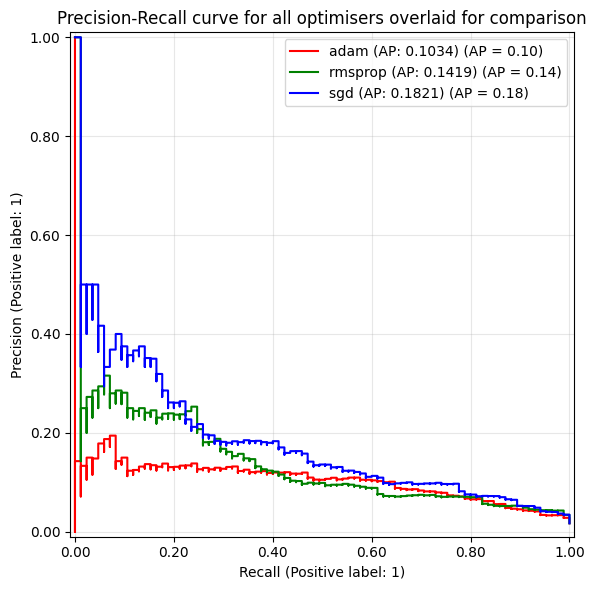

Saved /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/precision_recall_comparison.png


In [16]:
#set the plot configuration
fig, ax = plt.subplots(figsize=(7, 6))
#loop over the optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in allResults:
        continue
    #loading the labels and probabilities and calculate average precision
    labels = allResults[currentOptimiser]["labels"]
    probabilities = allResults[currentOptimiser]["probabilities"]
    averagePrecision = allResults[currentOptimiser]["metrics"]["Average Precision"]
    lineColour = optimiserColours[currentOptimiser]
    PrecisionRecallDisplay.from_predictions(labels, probabilities, name=f"{currentOptimiser} (AP: {averagePrecision})", color=lineColour, ax=ax)
#set title and grid and labels
ax.set_title("Precision-Recall curve for all optimisers overlaid for comparison")
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter("%.2f"))
#set the location of the legend
ax.legend(loc="upper right")
#shrinking layout to fit better side by side
plt.tight_layout()
#saving to file and then printing and displaying plot
savePath = os.path.join(trained, "precision_recall_comparison.png")
plt.savefig(savePath, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved {savePath}")

Precision–recall curves are used to evaluate malignant class performance more directly. This visualisation is especially useful for imbalanced datasets because it focuses on the relationship between precision and recall without being influenced by the large number of true negatives. The average precision score is also included in the legend.

The overlaid precision–recall curve shows that all three models struggled to maintain precision as recall increased. This confirms that malignant detection remained difficult despite the relatively strong ROC AUC results. SGD (blue) produced the strongest overall balance on this plot, while Adam (red) maintained high recall at the cost of especially poor precision. RMSprop (green) again performed between the other two.

This visualisation is particularly important because it highlights a limitation that is less visible in the ROC curves. It shows that the models were capable of detecting malignant cases, but often did so by producing too many false positives.

The next stage examines the training history to understand how the optimisers behaved during training and validation. Before this stage, the history csv files will be loaded and printed to confirm that they were read correctly.

In [ ]:
#definig a dictionary to store history data
historyData = {}
#looping over the optimiser list and loading in the optimiser history
for currentOptimiser in optimiserList:
    historyPath = os.path.join(trained, f"history_{currentOptimiser}.csv")
    historyExists = os.path.exists(historyPath)
    #if history.csv exists load and the content and print
    if historyExists:
        historyDf = pd.read_csv(historyPath)
        historyData[currentOptimiser] = historyDf
        print(f"Loaded {historyPath}")
        print(f"Epochs recorded: {len(historyDf)}")
        print()
#printing to total epochs recorded
print(f"{len(historyData)} history files loaded")

Loaded /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/history_adam.csv
Epochs recorded: 10

Loaded /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/history_rmsprop.csv
Epochs recorded: 10

Loaded /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/history_sgd.csv
Epochs recorded: 10

3 history files loaded


The loaded files contain the training and validation loss and accuracy for each optimiser. These histories are required for the next set of visualisations, which focus on learning behaviour rather than final test performance.

Below, individual training curves will be plotted for each optimiser. Separate line plots will be used to display the training and validation accuracy, followed by training and validation loss. Line plots are appropriate here because they show how model performance changed across epochs, making changes in learning behaviour easier to observe. These plots are useful for identifying whether an optimiser learned steadily, reached its strongest validation performance earlier, or showed signs of overfitting.

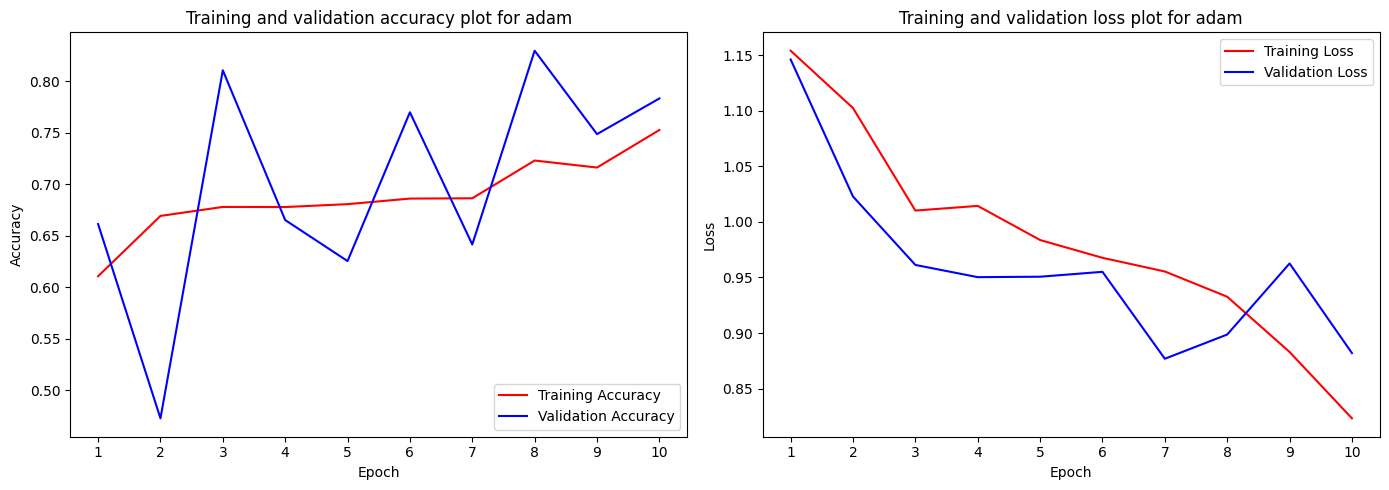

Saved /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/training_validation_adam.png


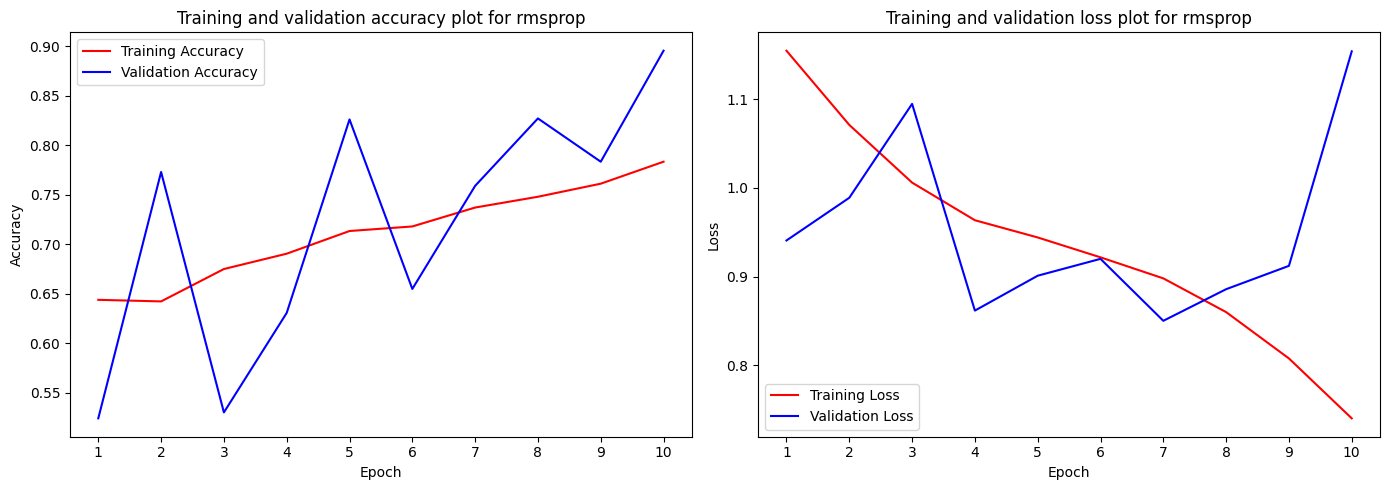

Saved /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/training_validation_rmsprop.png


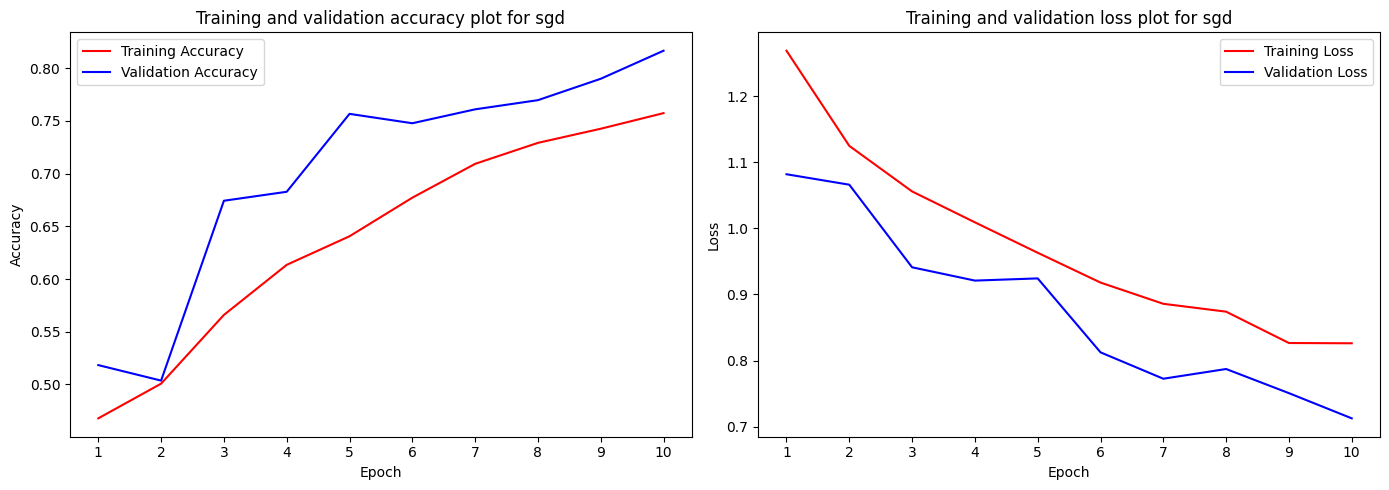

Saved /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/training_validation_sgd.png


In [ ]:
#looping over optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in historyData:
        continue
    #getting optimiser history and epochs
    historyDf = historyData[currentOptimiser]
    epochs = historyDf["epoch"].values
    #defining the plot configuration
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    #plotting the content of the first graph
    axes[0].plot(epochs, historyDf["trainingAccuracy"], color="red", label="Training Accuracy")
    axes[0].plot(epochs, historyDf["validationAccuracy"], color="blue", label="Validation Accuracy")
    #setting title, label and legend of the plot
    axes[0].set_title(f"Training and validation accuracy plot for {currentOptimiser}")
    axes[0].set_ylabel("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_xticks(epochs)
    axes[0].legend()
    #plotting the content of the second graph
    axes[1].plot(epochs, historyDf["trainingloss"], color="red", label="Training Loss")
    axes[1].plot(epochs, historyDf["validationloss"], color="blue", label="Validation Loss")
    #setting title, label and legend of the plot
    axes[1].set_title(f"Training and validation loss plot for {currentOptimiser}")
    axes[1].set_ylabel("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_xticks(epochs)
    axes[1].legend()
    #shrinking layout to fit better side by side
    plt.tight_layout()
    #saving to file and then printing and displaying plot
    savePath = os.path.join(trained, f"training_validation_{currentOptimiser}.png")
    plt.savefig(savePath, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved {savePath}")

The individual training curves show clear differences in optimiser behaviour. In these plots, the red lines represent training accuracy and training loss, while the blue lines represent validation accuracy and validation loss. The first set of plots shows that Adam learned quickly and reached its best validation performance at epoch 7. The second set shows that RMSprop followed a similar pattern and also achieved its best validation result at epoch 7. In contrast, the third set shows that SGD completed all 10 epochs and showed the most gradual and stable improvement throughout training.

The accuracy curves show that Adam and RMSprop both experienced greater fluctuation in validation accuracy across epochs, even though training accuracy continued to rise more steadily. This suggests that both optimisers were learning quickly on the training data but were less consistent on unseen validation samples. Adam showed the sharpest variation, including a large drop in validation accuracy around epoch 2, while RMSprop also rose and fell repeatedly across training.

In contrast, SGD showed a smoother progression in both training and validation accuracy. Its validation accuracy increased more steadily over time, suggesting a more gradual and consistent learning process.

The loss curves support this pattern. Adam and RMSprop both reduced training loss, but their validation loss remained more inconsistant, rising and falling rather than decreasing consistently. By comparison, SGD showed the most stable loss behaviour overall, with both training and validation loss generally decreasing across the full training period. This steadier optimisation path may help explain why SGD produced the strongest performance on the unseen test set.

To compare convergence behaviour more directly, the optimiser histories are next overlaid on combined plots.

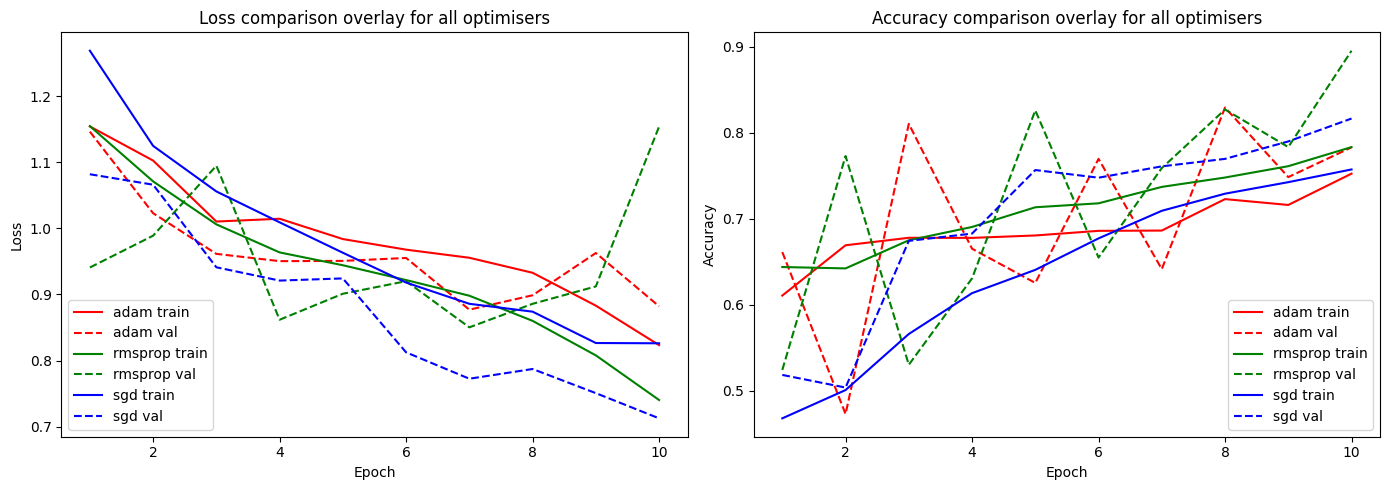

Saved /Users/craig/Documents/GitHub/melanoma_webapp_classifier/model/trained/combined_comparison_plot.png


In [ ]:
#setting colours for each optimiser 
optimiserColours = {"adam": "red", "rmsprop": "green", "sgd": "blue"}
#defining the configuration of the plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
#looping over the optimiser list
for currentOptimiser in optimiserList:
    if currentOptimiser not in historyData:
        continue
    #getting the saved history for the current optimiser, along with epoch and asigning colour
    historyDf = historyData[currentOptimiser]
    epochs = historyDf["epoch"].values
    lineColour = optimiserColours[currentOptimiser]
    #plot the content of the first graph
    axes[0].plot(epochs, historyDf["trainingloss"], color=lineColour, label=f"{currentOptimiser} train")
    axes[0].plot(epochs, historyDf["validationloss"], color=lineColour, linestyle="--", label=f"{currentOptimiser} val")
    #plotting the content of the second graph
    axes[1].plot(epochs, historyDf["trainingAccuracy"], color=lineColour, label=f"{currentOptimiser} train")
    axes[1].plot(epochs, historyDf["validationAccuracy"], color=lineColour, linestyle="--", label=f"{currentOptimiser} val")
#defining the title and labels along with legend for the first plot
axes[0].set_title("Loss comparison overlay for all optimisers")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
#defining the title and labels along with legend for the seoncd plot
axes[1].set_title("Accuracy comparison overlay for all optimisers")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
#shrinking layout to fit better side by side
plt.tight_layout()
#saving to file and then printing and displaying plot
savePath = os.path.join(trained, "combined_comparison_plot.png")
plt.savefig(savePath, dpi=150, bbox_inches="tight")
print()
plt.show()
print(f"Saved {savePath}")

This comparison overlay makes the accuracy and loss trends easier to compare across all three optimisers. It shows more clearly that SGD (blue) followed the most stable validation trend, particularly in validation loss, while Adam (red) and RMSprop (green) fluctuated more across training. Towards epoch 10, SGD’s training and validation curves remain close, showing a convergence between learning on the training data and performance on unseen validation data. This pattern suggests better stability and generalisation. In contrast, both Adam and RMSprop show increasing separation between their training and validation curves as they approach epoch 10, especially in the loss plots. This divergence indicates that while training performance continued to improve, validation performance did not follow the same trend as consistently. Overall, the overlay reinforces the earlier result that SGD improved more gradually but generalised more effectively by the end of training.

A performance summary table will now be created to bring together the key training history values for each optimiser. This table combines both training history and final test set evaluation metrics, providing a complete easy to view comparison. This allows the most important results to be viewed together before the final written evaluation.

In [ ]:
#define variable for summary data
finalOptimiserSummary = {}
#loop over optmiser data and skip of missing data found
for currentOptimiser in optimiserList:
    if currentOptimiser not in historyData:
        continue
    if currentOptimiser not in allResults:
        continue
    
    #store the history data from the current optimiser and the total epochs
    historyDf = historyData[currentOptimiser]
    totalEpochs = len(historyDf)
    #find the epoch with the best values based on the lowest validation loss
    bestEpochRow = historyDf.loc[historyDf["validationloss"].idxmin()]
    bestEpoch = int(bestEpochRow["epoch"])
    bestValLoss = round(bestEpochRow["validationloss"], 4)
    bestValAcc = round(bestEpochRow["validationAccuracy"], 4)
    finalTrainLoss = round(historyDf["trainingloss"].iloc[-1], 4)
    finalTrainAcc = round(historyDf["trainingAccuracy"].iloc[-1], 4)
    #storing summary values based on current optimiser
    finalOptimiserSummary[currentOptimiser] = {
        "Recorded Training Epochs": totalEpochs,
        "Best Validation Epoch": bestEpoch,
        "Best Validation Loss": bestValLoss,
        "Best Validation Accuracy": bestValAcc,
        "Final Train Loss": finalTrainLoss,
        "Final Train Accuracy": finalTrainAcc,
        "Accuracy": round(allResults[currentOptimiser]["metrics"]["Accuracy"], 4),
        "Precision": round(allResults[currentOptimiser]["metrics"]["Precision"], 4),
        "Recall": round(allResults[currentOptimiser]["metrics"]["Recall"], 4),
        "F1 Score": round(allResults[currentOptimiser]["metrics"]["F1 Score"], 4),
        "ROC AUC": round(allResults[currentOptimiser]["metrics"]["ROC AUC"], 4)
    }
#saving a displaying table
finalOptimiserSummaryDf = pd.DataFrame(finalOptimiserSummary)
print("Final Optimiser Performance Summary")
display(finalOptimiserSummaryDf)

Final Optimiser Performance Summary


,adam,rmsprop,sgd
Recorded Training Epochs,10.0000,10.0000,10.0000
Best Validation Epoch,7.0000,7.0000,10.0000
Best Validation Loss,0.8769,0.8502,0.7126
Best Validation Accuracy,0.6415,0.7590,0.8166
Final Train Loss,0.8233,0.7403,0.8261
Final Train Accuracy,0.7525,0.7834,0.7574
Accuracy,0.6154,0.7276,0.7979
Precision,0.0405,0.0519,0.0697
Recall,0.9412,0.8588,0.8706
F1 Score,0.0777,0.0979,0.1291


The combined summary table provides an overall comparison of each optimiser’s performance from training through to final test evaluation. Across most metrics, SGD produced the strongest results, achieving the highest test accuracy of 0.7979, precision of 0.0697, F1 score of 0.1291, and ROC AUC of 0.9024. Adam achieved the highest recall of 0.9412, meaning it was the most sensitive at identifying malignant cases. However, this came at the cost of lower precision and accuracy, as it produced the highest number of false positives. RMSprop generally performed between Adam and SGD across most metrics.

All three optimisers achieved strong ROC AUC scores above 0.87, suggesting that the models were able to separate the two classes effectively across different classification thresholds. However, the precision–recall curves revealed a different limitation. In all cases, precision decreased rapidly as recall increased, showing that the models struggled to maintain reliable malignant predictions. This difference between ROC and precision–recall results highlight the importance of evaluating imbalanced datasets using multiple metrics rather than relying on a single measure.

The confusion matrices further showed that the models prioritised malignant recall over benign precision. This behaviour is consistent with the positive class weighting applied to the loss function during training. While this increased sensitivity to malignant cases, it also increased the number of benign images incorrectly classified as malignant. The macro average F1 scores, ranging from 0.4174 to 0.5074, highlighted a clear performance gap between the two classes that was less visible when examining the weighted averages.

The training curves also showed different convergence behaviour for each optimiser. Adam achieved its lowest validation loss at epoch 7, while RMSprop also achieved its best validation loss at epoch 7. In contrast, SGD continued improving more gradually and achieved its lowest validation loss at epoch 10 after completing the full 10 epochs. This slower but more consistent learning process likely contributed to its stronger performance on the test dataset.

The batch size was set to 16 due to hardware limitations. Larger batches of 32 were attempted but resulted in crashes and complete software lock-ups during training. Additional training cycles with alternative configurations were considered. However, these were limited by both hardware constraints and the available project timeframe. Each full training cycle across the three optimisers took approximately three hours to complete, during which the hardware was effectively unusable due to the processing resources required.

Class imbalance was addressed through the use of a positive weight in the BCEWithLogitsLoss function, giving greater emphasis to the malignant class during training. Additionally, techniques such as data augmentation or synthetic oversampling could increase the representation of malignant samples in the training data, although these were not implemented due to the 8 GB memory limitation of the training hardware. Futhermore, A fixed threshold of 0.5 was used to classify predictions as either benign or malignant. Alternative threshold values were considered alongside weighted class values. However, due to time constraints, this was not investigated further.

All three optimisers used during training were assigned the same learning rate of 0.0005 to maintain a fair comparison. However, different optimisers can benefit from different learning rate settings. Further training using more suitable learning rates for each could produce stronger results. With regards to training, it was also limited to 10 epochs, and increasing this limit while tuning early stopping patience could allow the model more time to learn malignant features. However, due to time constraints, this could not be explored further.

Overall, SGD was the strongest optimiser for this project because, as shown throughout the evaluation, it provided the best overall balance between classification performance, training stability, and generalisation on the unseen test set. Although Adam achieved the highest malignant recall, this came at the cost of a much higher false positive rate, while RMSprop generally performed between the other two. Based on these results, SGD was the most suitable choice for the model implemented in the Spot Check Medical web application, and these findings will be used in the final report to support the evaluation, discussion of limitations, and justification for selecting the final optimiser.